# Training a CNN model using TensorFlow

In [24]:
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Dropout, BatchNormalization, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import itertools
import os
import shutil
import random
import glob
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [25]:
# Load the dataset
train_path = 'crab-images-dataset/train'
valid_path = 'crab-images-dataset/valid'
test_path = 'crab-images-dataset/test'

In [34]:
#Split dataset into train, valid, test batches
train_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input) \
    .flow_from_directory(directory=train_path, target_size=(64,64), classes=['dungeness_crab','fiddler_crab','hermit_crab','king_crab','rock_crab'], 
                         batch_size=10)
valid_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input) \
    .flow_from_directory(directory=valid_path, target_size=(64,64), classes=['dungeness_crab','fiddler_crab','hermit_crab','king_crab','rock_crab'], 
                         batch_size=10)
test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input) \
    .flow_from_directory(directory=test_path, target_size=(64,64), classes=['dungeness_crab','fiddler_crab','hermit_crab','king_crab','rock_crab'], 
                         batch_size=10, shuffle=False)

Found 3833 images belonging to 5 classes.
Found 1157 images belonging to 5 classes.
Found 1369 images belonging to 5 classes.


In [35]:
imgs, labels = next(train_batches)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..150.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-118.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-116.779..148.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-114.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data

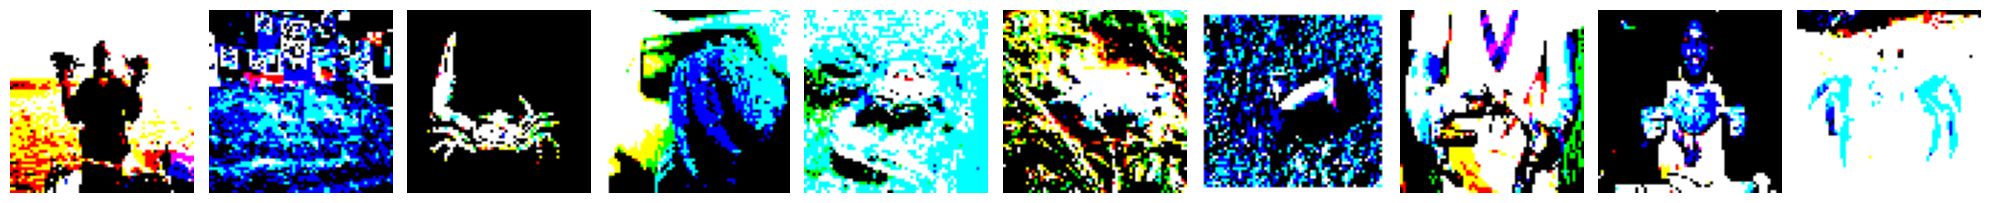

In [36]:
def plotImages(images_arr):
    fig, axes = plt.subplots(1, 10, figsize=(20,20))
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

plotImages(imgs)

In [37]:
# Build and define model using Sequential()
model = Sequential([
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same', input_shape=(64,64,3)),
    BatchNormalization(),
    MaxPool2D(pool_size=(2,2), strides=2),
    Dropout(0.1),

    Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2,2), strides=2),
    Dropout(0.1),

    Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(pool_size=(2,2), strides=2),
    Dropout(0.1),

    Flatten(),
    Dense(units=128, activation='relu'),
    Dropout(0.3),
    Dense(units=5, activation='softmax')
])

In [38]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,143,493 (4.36 MB)

 Trainable params: 1,143,045 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [39]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss = 'categorical_crossentropy', metrics=['accuracy'])

In [40]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [41]:
# Train the model
model.fit(train_batches, validation_data=valid_batches, epochs=25, verbose=1, callbacks=[early_stop])

Epoch 1/25
384/384 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.3062 - loss: 1.9301 - val_accuracy: 0.4192 - val_loss: 1.3981
Epoch 2/25
384/384 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.4207 - loss: 1.3537 - val_accuracy: 0.4192 - val_loss: 1.3690
Epoch 3/25
384/384 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - accuracy: 0.4637 - loss: 1.2354 - val_accuracy: 0.4434 - val_loss: 1.4144
Epoch 4/25
384/384 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - accuracy: 0.5079 - loss: 1.2041 - val_accuracy: 0.4693 - val_loss: 1.3338
Epoch 5/25
384/384 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.5496 - loss: 1.1146 - val_accuracy: 0.4589 - val_loss: 1.3922
Epoch 6/25
384/384 ━━━━━━━━━━━━━━━━━━━━ 25s 66ms/step - accuracy: 0.5781 - loss: 1.0406 - val_accuracy: 0.4581 - val_loss: 1.4136
Epoch 7/25
384/384 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.5965 - loss: 0.9893 - val_accuracy: 0.4408 - val_loss: 1.5800
Epoch 8/25
384/384 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.6181 - loss: 0.9342 - 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-116.779..147.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-121.68..146.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-120.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..143.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-122.68..131.32].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..138.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].
Clipping input data 

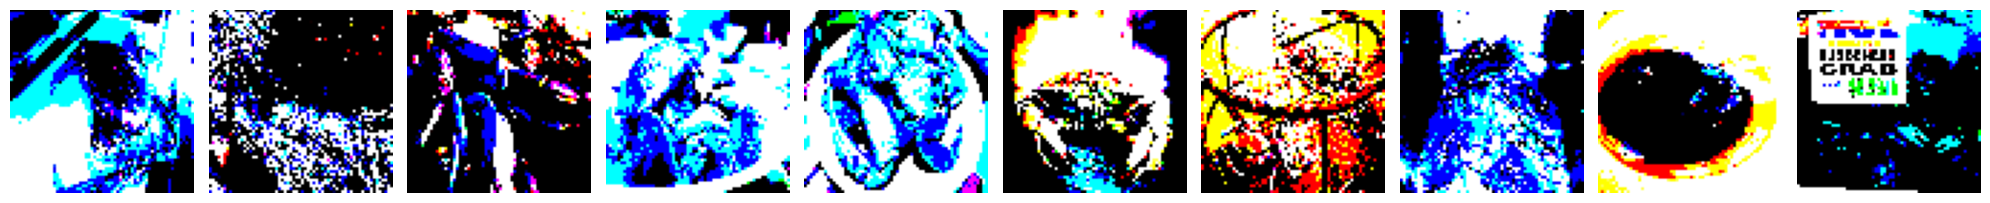

[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]]


In [42]:
test_imgs, test_labels = next(test_batches)
plotImages(test_imgs)
print(test_labels)

In [43]:
test_batches.classes

array([0, 0, 0, ..., 4, 4, 4], dtype=int32)

In [50]:
# Evaluate the model
loss, accuracy = model.evaluate(test_batches)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.4580 - loss: 1.4490
Test Loss: 1.4234615564346313, Test Accuracy: 0.4390065670013428


In [51]:
# Model prediction
predictions = model.predict(x=test_batches, verbose=0)

In [52]:
np.round(predictions)

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0.],
       ...,
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]], dtype=float32)

Confusion matrix, without Normalization
[[ 30  12  38  28   8]
 [ 12 195  99  11  35]
 [  6  16  93   4  13]
 [ 72  25  83 184  32]
 [ 34 104 109  27  99]]


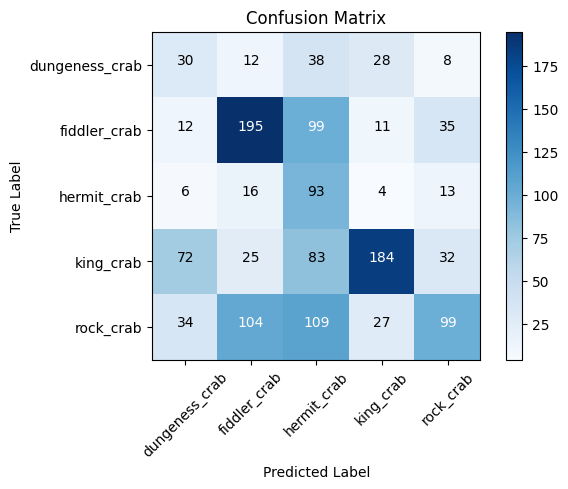

In [56]:
# Confusion Matrix
def plot_confusion_matrix(cm, 
                          classes, 
                          normalize=False, 
                          title='Confusion Matrix', 
                          cmap=plt.cm.Blues):
  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks= np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    print("Normalize confusion matrix")
  else:
    print("Confusion matrix, without Normalization")

  print(cm)

  thresh = cm.max() / 2
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, cm[i, j],
               horizontalalignment="center",
               color="white" if cm[i,j] > thresh else "black")

  plt.tight_layout()
  plt.ylabel('True Label')
  plt.xlabel('Predicted Label')
  plt.savefig("model_cm")

cm = confusion_matrix(y_true=test_batches.classes, y_pred=np.argmax(predictions, axis=-1))
cm_plot_labels = ['dungeness_crab','fiddler_crab','hermit_crab','king_crab','rock_crab']
plot_confusion_matrix(cm=cm, classes=cm_plot_labels, title='Confusion Matrix')

In [57]:
test_batches.class_indices

{'dungeness_crab': 0,
 'fiddler_crab': 1,
 'hermit_crab': 2,
 'king_crab': 3,
 'rock_crab': 4}

In [58]:
# Classification report of predict vs actual result
from sklearn.metrics import classification_report

#Get highest probability class
predicted_classes = np.argmax(predictions, axis=1)  # Get highest probability class

# Get actual labels
true_classes = test_batches.classes

print(classification_report(true_classes, predicted_classes, target_names=test_batches.class_indices.keys()))

                precision    recall  f1-score   support

dungeness_crab       0.19      0.26      0.22       116
  fiddler_crab       0.55      0.55      0.55       352
   hermit_crab       0.22      0.70      0.34       132
     king_crab       0.72      0.46      0.57       396
     rock_crab       0.53      0.27      0.35       373

      accuracy                           0.44      1369
     macro avg       0.44      0.45      0.41      1369
  weighted avg       0.53      0.44      0.45      1369

